Titanic Survival Prediction




In [36]:
from google.colab import files
uploaded = files.upload()

Saving gender_submission.csv to gender_submission (1).csv
Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


In [ ]:
import sys
print(sys.executable)

/usr/bin/python3


In [ ]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn

<a id="1"></a>
## 1. Library Installation




In [ ]:
# Uncomment the line below if a library is not yet installed in your environment
# !pip install pandas numpy matplotlib seaborn scikit-learn

# Import all libraries required for this project
import pandas as pd                      # Data loading and manipulation
import numpy as np                       # Numerical operations
import matplotlib.pyplot as plt          # Plotting
import seaborn as sns                    # Statistical visualizations

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Make plots look clean and consistent
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Ensure results are reproducible every time the notebook is run
RANDOM_STATE = 42

print("All libraries imported successfully.")

All libraries imported successfully.


<a id="2"></a>
## 2. Data Loading




In [ ]:
# Load the training and test datasets (uploaded directly to Colab)
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Keep a copy of PassengerId from the test set -- we will need it later
# when building the final submission.csv file
test_passenger_ids = test_df["PassengerId"]

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

Training data shape: (891, 12)
Test data shape: (418, 11)


<a id="3"></a>
## 3. Data Understanding




In [ ]:
# Look at the first 5 rows of the training data
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Get a concise summary: column names, data types, and non-null counts
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Get statistical summary of numerical columns
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Check how many missing values each column has
train_df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [ ]:
# Check the balance of our target variable (Survived)
train_df["Survived"].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


<a id="4"></a>
## 4. Data Cleaning & Preprocessing




In [ ]:
# Add a temporary column to identify which rows came from train vs test
train_df["dataset_source"] = "train"
test_df["dataset_source"] = "test"

# Combine both datasets for consistent cleaning
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True, sort=False)

print("Combined dataset shape:", combined_df.shape)

Combined dataset shape: (1309, 13)


<a id="5"></a>
## 5. Handling Missing Values




In [ ]:
# Fill missing Age values with the median age
combined_df["Age"] = combined_df["Age"].fillna(combined_df["Age"].median())

# Fill missing Embarked values with the most frequent port
combined_df["Embarked"] = combined_df["Embarked"].fillna(combined_df["Embarked"].mode()[0])

# Fill the single missing Fare value with the median fare
combined_df["Fare"] = combined_df["Fare"].fillna(combined_df["Fare"].median())

# Cabin has too many missing values to fill reliably.
# Instead, create a new binary feature: 1 if cabin is known, 0 if missing.
combined_df["Has_Cabin"] = combined_df["Cabin"].notnull().astype(int)

# Confirm there are no more missing values in the columns we care about
print(combined_df[["Age", "Embarked", "Fare", "Has_Cabin"]].isnull().sum())

Age          0
Embarked     0
Fare         0
Has_Cabin    0
dtype: int64


<a id="6"></a>
## 6. Encoding Categorical Variables




In [ ]:
# Encode 'Sex': male -> 0, female -> 1
le_sex = LabelEncoder()
combined_df["Sex"] = le_sex.fit_transform(combined_df["Sex"])

# Encode 'Embarked': C/Q/S -> 0/1/2
le_embarked = LabelEncoder()
combined_df["Embarked"] = le_embarked.fit_transform(combined_df["Embarked"])

# Feature engineering: family size and whether the passenger is alone
combined_df["FamilySize"] = combined_df["SibSp"] + combined_df["Parch"] + 1
combined_df["IsAlone"] = (combined_df["FamilySize"] == 1).astype(int)

combined_df[["Sex", "Embarked", "FamilySize", "IsAlone"]].head()

,Sex,Embarked,FamilySize,IsAlone
0,1,2,2,0
1,0,0,2,0
2,0,2,1,1
3,0,2,2,0
4,1,2,1,1


<a id="7"></a>
## 7. Exploratory Data Analysis (EDA)



In [ ]:
# Split combined data back into train and test using our source flag
train_clean = combined_df[combined_df["dataset_source"] == "train"].drop(columns=["dataset_source"]).copy()
test_clean = combined_df[combined_df["dataset_source"] == "test"].drop(columns=["dataset_source", "Survived"]).copy()

# Survived was read in as float during concat (due to NaNs in test) -- convert back to int
train_clean["Survived"] = train_clean["Survived"].astype(int)

print("Train (clean) shape:", train_clean.shape)
print("Test (clean) shape:", test_clean.shape)

Train (clean) shape: (891, 15)
Test (clean) shape: (418, 14)


/tmp/ipykernel_503/1507103542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_clean, x="Survived", palette="Set2")


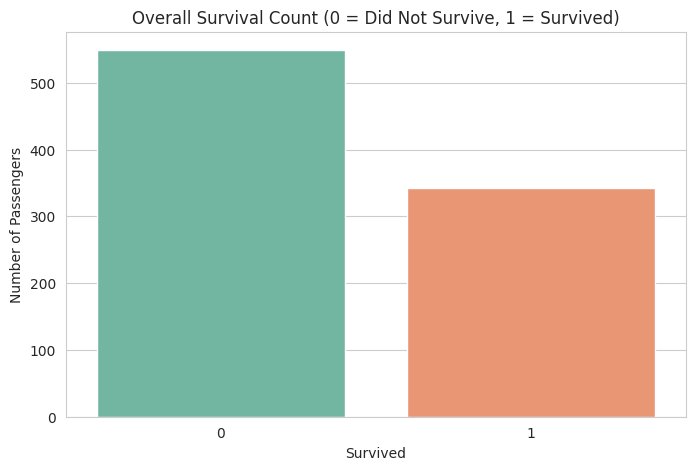

In [ ]:
# 7.1 Overall survival count
plt.figure()
sns.countplot(data=train_clean, x="Survived", palette="Set2")
plt.title("Overall Survival Count (0 = Did Not Survive, 1 = Survived)")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

/tmp/ipykernel_503/2634329304.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_clean, x="Sex", y="Survived", palette="Set2")


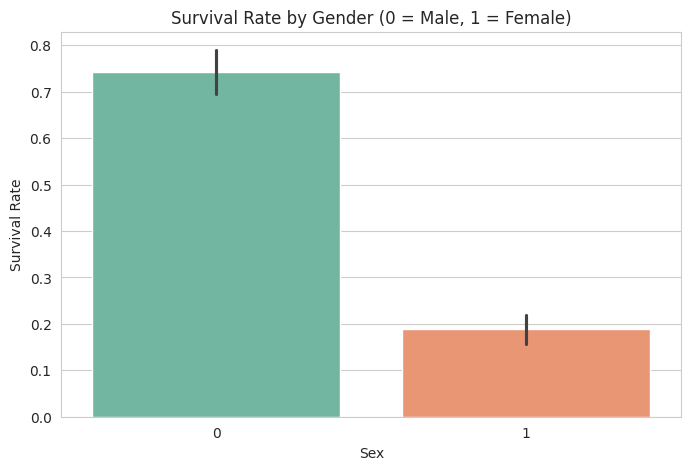

In [ ]:
# 7.2 Survival rate by gender
plt.figure()
sns.barplot(data=train_clean, x="Sex", y="Survived", palette="Set2")
plt.title("Survival Rate by Gender (0 = Male, 1 = Female)")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

/tmp/ipykernel_503/3804098064.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_clean, x="Pclass", y="Survived", palette="Set2")


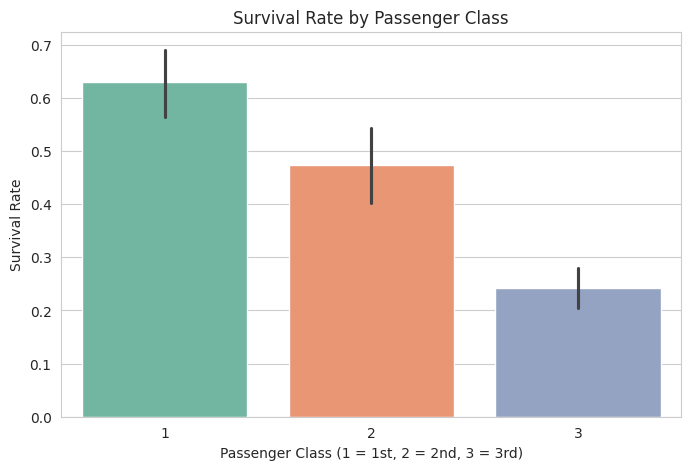

In [ ]:
# 7.3 Survival rate by passenger class
plt.figure()
sns.barplot(data=train_clean, x="Pclass", y="Survived", palette="Set2")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)")
plt.ylabel("Survival Rate")
plt.show()

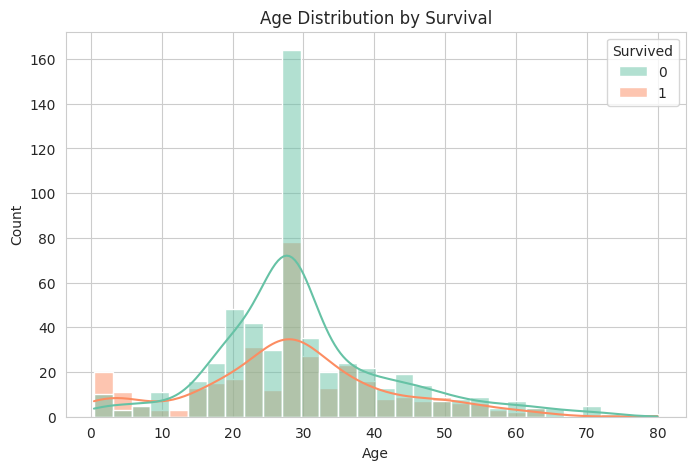

In [ ]:
# 7.4 Age distribution split by survival
plt.figure()
sns.histplot(data=train_clean, x="Age", hue="Survived", bins=30, kde=True, palette="Set2")
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_503/2028863866.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_clean, x="Survived", y="Fare", palette="Set2")


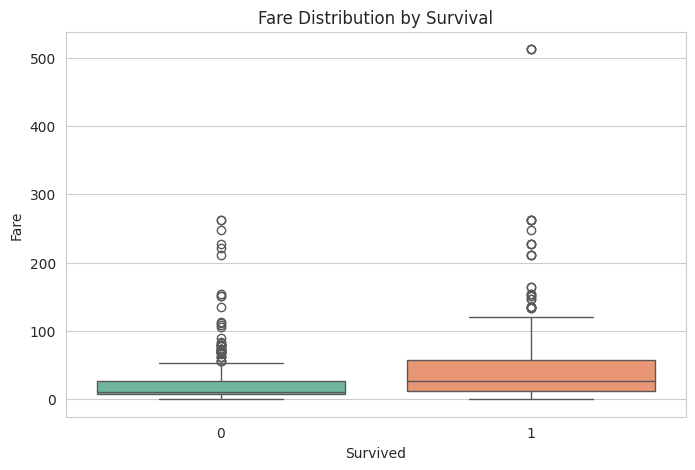

In [ ]:
# 7.5 Fare distribution split by survival
plt.figure()
sns.boxplot(data=train_clean, x="Survived", y="Fare", palette="Set2")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

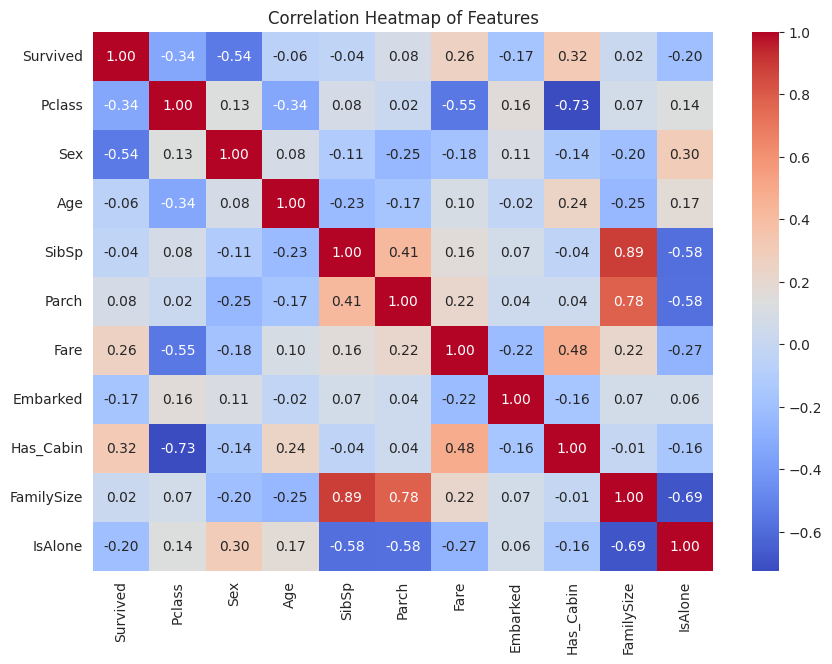

In [ ]:
# 7.6 Correlation heatmap of numeric features
plt.figure(figsize=(10, 7))
numeric_cols = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch",
                 "Fare", "Embarked", "Has_Cabin", "FamilySize", "IsAlone"]
corr = train_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Features")
plt.show()

<a id="8"></a>
## 8. Feature Selection



In [ ]:
# Columns to drop (identifiers / raw text / already-engineered columns)
drop_cols = ["PassengerId", "Name", "Ticket", "Cabin"]

# Define our final feature set (X) and target (y) for training
X = train_clean.drop(columns=drop_cols + ["Survived"])
y = train_clean["Survived"]

# Apply the same column drops to the test set (used later for prediction)
X_final_test = test_clean.drop(columns=drop_cols)

print("Feature columns used for modeling:")
print(X.columns.tolist())

Feature columns used for modeling:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Has_Cabin', 'FamilySize', 'IsAlone']


<a id="9"></a>
## 9. Train-Test Split




In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,   # keeps the same survival ratio in both splits
)

print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)

Training set size: (712, 10)
Validation set size: (179, 10)


<a id="10"></a>
## 10. Model Building




In [ ]:
# --- Model 1: Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)

log_reg_preds = log_reg.predict(X_val)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [ ]:
# --- Model 2: Random Forest Classifier ---
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=RANDOM_STATE,
)
rf_clf.fit(X_train, y_train)

rf_preds = rf_clf.predict(X_val)

print("Random Forest trained successfully.")

Random Forest trained successfully.


<a id="11"></a>
## 11. Compare Model Performance




In [ ]:
def get_metrics(y_true, y_pred):
    """Return a dictionary of the four core classification metrics."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
    }

log_reg_metrics = get_metrics(y_val, log_reg_preds)
rf_metrics = get_metrics(y_val, rf_preds)

comparison_df = pd.DataFrame(
    {"Logistic Regression": log_reg_metrics, "Random Forest": rf_metrics}
).round(4)

comparison_df

,Logistic Regression,Random Forest
Accuracy,0.8101,0.7933
Precision,0.7692,0.7759
Recall,0.7246,0.6522
F1 Score,0.7463,0.7087


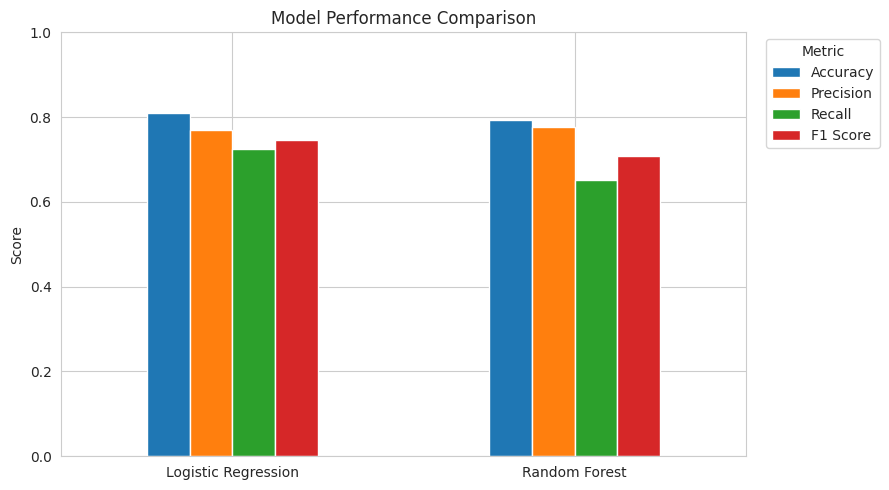

In [ ]:
# Visual comparison of the two models
comparison_df.T.plot(kind="bar", figsize=(9, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# Automatically select the better-performing model based on Accuracy
if rf_metrics["Accuracy"] >= log_reg_metrics["Accuracy"]:
    best_model = rf_clf
    best_model_name = "Random Forest"
else:
    best_model = log_reg
    best_model_name = "Logistic Regression"

print(f"Best performing model: {best_model_name}")

Best performing model: Logistic Regression


<a id="12"></a>
## 12. Model Evaluation (Best Model)



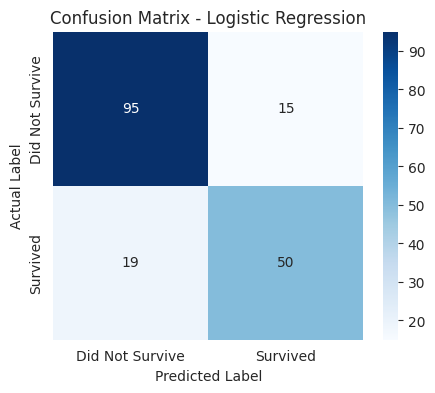

In [ ]:
best_preds = best_model.predict(X_val)

# Confusion Matrix: shows True Negatives, False Positives, False Negatives, True Positives
cm = confusion_matrix(y_val, best_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Did Not Survive", "Survived"],
            yticklabels=["Did Not Survive", "Survived"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
# Detailed classification report: precision, recall, f1-score per class
print(f"Classification Report - {best_model_name}\n")
print(classification_report(y_val, best_preds, target_names=["Did Not Survive", "Survived"]))

Classification Report - Logistic Regression

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.85       110
       Survived       0.77      0.72      0.75        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179



In [ ]:
# Feature importance (only meaningful for the Random Forest model)
if best_model_name == "Random Forest":
    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
    plt.title("Feature Importance - Random Forest")
    plt.tight_layout()
    plt.show()

    print(importance_df)
else:
    print("Feature importance plot is shown only when Random Forest is the best model.")

Feature importance plot is shown only when Random Forest is the best model.


<a id="13"></a>
## 13. Predict on the Test Dataset



In [ ]:
# Make sure the test feature columns are in the same order as training features
X_final_test = X_final_test[X.columns]

# Generate final survival predictions for the test set
final_predictions = best_model.predict(X_final_test)

print("Number of predictions generated:", len(final_predictions))
print("Sample predictions:", final_predictions[:10])

Number of predictions generated: 418
Sample predictions: [0 0 0 0 1 0 1 0 1 0]


<a id="14"></a>
## 14. Save Predictions to submission.csv




In [ ]:
submission_df = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": final_predictions,
})

# Save to the submission folder
submission_df.to_csv("submission.csv", index=False)

print("submission.csv saved successfully!")
submission_df.head()

submission.csv saved successfully!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [ ]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>